# Mission 1: Inside the Smart Hospital
## Project: Smart Hospital Patient Navigator

----------

## What You Will Learn

 In this lesson you will explore K-Nearest Neighbors (KNN) — a completely different way of thinking about classification — and apply it to a real healthcare problem.

By the end of this notebook you will be able to:
- Preprocess a real hospital dataset (encoding, cleaning, scaling)
- Explain how the KNN algorithm works
- Train a KNN classifier to predict hospital department
- Save the model for deployment
- Make predictions with user input

---------

> **Key Idea:** There is no single best algorithm. The right model depends on your data, your problem, and what matters most — speed, accuracy, or interpretability.

## Step 1: Import Libraries

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import pickle
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded!')

Libraries loaded!


## Step 2: Load the Dataset


In [45]:
# Load dataset from Gdrive
url = "https://drive.google.com/uc?id=1Ajij0aEnlkkAw3jseCax9Et41WDTGz-h"

df = pd.read_csv(url)

df.head(10)

,patient_id,age,gender,fever,cough,headache,chest_pain,stomach_pain,shortness_breath,nausea_vomiting,...,skin_rash,temperature_level,heart_rate_level,duration,diabetes,asthma,hypertension,heart_disease,chief_complaint,department
0,PAT-000001,51,Female,Yes,Yes,No,No,No,No,No,...,No,Above 38°C,60-100 bpm,More than 1 week,No,No,No,No,Fever,Respiratory Medicine
1,PAT-000002,27,Male,Yes,Yes,No,No,No,Yes,No,...,No,Above 38°C,60-100 bpm,Less than 1 day,No,Yes,No,No,Shortness of Breath,Respiratory Medicine
2,PAT-000003,25,Female,Yes,Yes,No,No,No,No,No,...,No,Above 38°C,Below 60 bpm,4-7 days,No,No,No,No,Shortness of Breath,Respiratory Medicine
3,PAT-000004,55,Male,Yes,Yes,No,No,No,No,No,...,No,Above 38°C,Below 60 bpm,4-7 days,No,No,No,No,Cough,Respiratory Medicine
4,PAT-000005,57,Female,Yes,Yes,No,No,No,Yes,No,...,No,Above 38°C,60-100 bpm,NaN,No,No,No,No,Fever,Respiratory Medicine
5,PAT-000006,55,Female,Yes,Yes,No,No,No,Yes,No,...,No,37-38°C,Above 100 bpm,1-3 days,No,Yes,No,No,Shortness of Breath,Respiratory Medicine
6,PAT-000007,46,Female,Yes,Yes,No,No,No,Yes,No,...,No,37-38°C,Above 100 bpm,4-7 days,No,No,No,No,Cough,Respiratory Medicine
7,PAT-000008,27,Male,Yes,Yes,No,No,No,Yes,No,...,No,Above 38°C,60-100 bpm,More than 1 week,No,No,No,No,Fever,Respiratory Medicine
8,PAT-000009,38,Male,Yes,Yes,No,No,No,Yes,No,...,No,37-38°C,Above 100 bpm,Less than 1 day,No,Yes,No,No,Shortness of Breath,Respiratory Medicine
9,PAT-000010,58,Male,Yes,Yes,No,No,No,No,No,...,No,37-38°C,60-100 bpm,4-7 days,No,Yes,No,No,Shortness of Breath,Respiratory Medicine


In [46]:
# Load dataset by uploading smart_hospital_patient_navigator_dataset.csv to your Colab session.
df = pd.read_csv('smart_hospital_patient_navigator_dataset.csv')

df.head(10)

,patient_id,age,gender,fever,cough,headache,chest_pain,stomach_pain,shortness_breath,nausea_vomiting,...,skin_rash,temperature_level,heart_rate_level,duration,diabetes,asthma,hypertension,heart_disease,chief_complaint,department
0,PAT-000001,51,Female,Yes,Yes,No,No,No,No,No,...,No,Above 38°C,60-100 bpm,More than 1 week,No,No,No,No,Fever,Respiratory Medicine
1,PAT-000002,27,Male,Yes,Yes,No,No,No,Yes,No,...,No,Above 38°C,60-100 bpm,Less than 1 day,No,Yes,No,No,Shortness of Breath,Respiratory Medicine
2,PAT-000003,25,Female,Yes,Yes,No,No,No,No,No,...,No,Above 38°C,Below 60 bpm,4-7 days,No,No,No,No,Shortness of Breath,Respiratory Medicine
3,PAT-000004,55,Male,Yes,Yes,No,No,No,No,No,...,No,Above 38°C,Below 60 bpm,4-7 days,No,No,No,No,Cough,Respiratory Medicine
4,PAT-000005,57,Female,Yes,Yes,No,No,No,Yes,No,...,No,Above 38°C,60-100 bpm,NaN,No,No,No,No,Fever,Respiratory Medicine
5,PAT-000006,55,Female,Yes,Yes,No,No,No,Yes,No,...,No,37-38°C,Above 100 bpm,1-3 days,No,Yes,No,No,Shortness of Breath,Respiratory Medicine
6,PAT-000007,46,Female,Yes,Yes,No,No,No,Yes,No,...,No,37-38°C,Above 100 bpm,4-7 days,No,No,No,No,Cough,Respiratory Medicine
7,PAT-000008,27,Male,Yes,Yes,No,No,No,Yes,No,...,No,Above 38°C,60-100 bpm,More than 1 week,No,No,No,No,Fever,Respiratory Medicine
8,PAT-000009,38,Male,Yes,Yes,No,No,No,Yes,No,...,No,37-38°C,Above 100 bpm,Less than 1 day,No,Yes,No,No,Shortness of Breath,Respiratory Medicine
9,PAT-000010,58,Male,Yes,Yes,No,No,No,No,No,...,No,37-38°C,60-100 bpm,4-7 days,No,Yes,No,No,Shortness of Breath,Respiratory Medicine


In [47]:
# Show the data
print(f'Rows    : {len(df):,}')
print(f'Columns : {len(df.columns)}')
print()
print('Target distribution:')
print(df['department'].value_counts())

Rows    : 102,000
Columns : 21

Target distribution:
department
Respiratory Medicine    23503
Cardiology              18359
Gastroenterology        17334
Neurology               16316
General Medicine        13246
Dermatology             13242
Name: count, dtype: int64


---
## Part A — Data Preprocessing
---

## Step 3: Clean and Encode the Data

This dataset has several issues we need to fix:
- `gender` has inconsistent casing (Female / FEMALE / female)
- `temperature_level` has inconsistent formats (Above 38°C vs Above 38)
- Missing values in gender, temperature_level, heart_rate_level, duration
- `diabetes` column only contains 'No' — not useful
- All text columns need to be converted to numbers (encoding)

In [48]:
# Gender values before cleaning
print('Gender values before cleaning:')
print(df['gender'].value_counts())

Gender values before cleaning:
gender
Female    47990
Male      47945
MALE        812
male        793
FEMALE      766
female      749
Name: count, dtype: int64


In [49]:
# Step 3a: Fix gender casing inconsistency
df['gender'] = df['gender'].str.strip().str.capitalize()
df['gender'] = df['gender'].fillna('unknown')

print('Gender values after cleaning:')
print(df['gender'].value_counts())

Gender values after cleaning:
gender
Male       49550
Female     49505
unknown     2945
Name: count, dtype: int64


In [51]:
# Temperature and heart rate level values before cleaning
print('Temperature Level values before cleaning:')
print(df['temperature_level'].value_counts())
print()
print('Heart rate level values before cleaning:')
print(df['heart_rate_level'].value_counts())

Temperature Level values before cleaning:
temperature_level
Above 38°C    40848
37-38°C       31671
Below 37°C    24635
Below 37        658
37 to 38        618
Above 38        607
Name: count, dtype: int64

Heart rate level values before cleaning:
heart_rate_level
60-100 bpm       36008
Above 100 bpm    35801
Below 60 bpm     27111
Name: count, dtype: int64


In [52]:
# Step 3b: Fix temperature_level inconsistencies
df['temperature_level'] = df['temperature_level'].replace({
    'Above 38'  : 'Above 38°C',
    'Below 37'  : 'Below 37°C',
    '37 to 38'  : '37-38°C'
})

# Fill missing values with most common
df['temperature_level'] = df['temperature_level'].fillna('37-38°C')
df['heart_rate_level']  = df['heart_rate_level'].fillna('60-100 bpm')
df['duration']          = df['duration'].fillna('1-3 days')

print('Temperature Level values after cleaning:')
print(df['temperature_level'].value_counts())
print()
print('Heart rate level values after cleaning:')
print(df['heart_rate_level'].value_counts())

Temperature Level values after cleaning:
temperature_level
Above 38°C    41455
37-38°C       35252
Below 37°C    25293
Name: count, dtype: int64

Heart rate level values after cleaning:
heart_rate_level
60-100 bpm       39088
Above 100 bpm    35801
Below 60 bpm     27111
Name: count, dtype: int64


In [53]:
# Patient ID and Diabetes data preview
print(df['patient_id'].value_counts())
print()
print(df['diabetes'].value_counts())

patient_id
PAT-045149    2
PAT-064798    2
PAT-067293    2
PAT-005604    2
PAT-002260    2
             ..
PAT-033679    1
PAT-033678    1
PAT-033677    1
PAT-033676    1
PAT-033689    1
Name: count, Length: 100000, dtype: int64

diabetes
No    102000
Name: count, dtype: int64


In [54]:
# Step 3c: Drop useless columns
# patient_id = just an ID, not a feature
# diabetes = always 'No' in this dataset, carries no information
df = df.drop(columns=['patient_id', 'diabetes'])
print(f'Columns after dropping: {df.columns.tolist()}')

Columns after dropping: ['age', 'gender', 'fever', 'cough', 'headache', 'chest_pain', 'stomach_pain', 'shortness_breath', 'nausea_vomiting', 'dizziness', 'skin_rash', 'temperature_level', 'heart_rate_level', 'duration', 'asthma', 'hypertension', 'heart_disease', 'chief_complaint', 'department']


In [55]:
# Data with Yes/No values
print(df['fever'].value_counts())
print()
print(df['cough'].value_counts())
print()
print(df['headache'].value_counts())
print()
print(df['chest_pain'].value_counts())
print()
print(df['stomach_pain'].value_counts())
print()
print(df['shortness_breath'].value_counts())
print()
print(df['nausea_vomiting'].value_counts())
print()
print(df['dizziness'].value_counts())
print()
print(df['skin_rash'].value_counts())
print()
print(df['asthma'].value_counts())
print()
print(df['hypertension'].value_counts())
print()
print(df['heart_disease'].value_counts())

fever
No     80051
Yes    21949
Name: count, dtype: int64

cough
No     76424
Yes    25576
Name: count, dtype: int64

headache
No     84145
Yes    17855
Name: count, dtype: int64

chest_pain
No     83521
Yes    18479
Name: count, dtype: int64

stomach_pain
No     82820
Yes    19180
Name: count, dtype: int64

shortness_breath
No     84316
Yes    17684
Name: count, dtype: int64

nausea_vomiting
No     87272
Yes    14728
Name: count, dtype: int64

dizziness
No     78868
Yes    23132
Name: count, dtype: int64

skin_rash
No     89448
Yes    12552
Name: count, dtype: int64

asthma
No     95008
Yes     6992
Name: count, dtype: int64

hypertension
No     90990
Yes    11010
Name: count, dtype: int64

heart_disease
No     93817
Yes     8183
Name: count, dtype: int64


In [56]:
# Step 3d: Encode Yes/No columns to 1/0
binary_cols = ['fever','cough','headache','chest_pain','stomach_pain',
               'shortness_breath','nausea_vomiting','dizziness','skin_rash',
               'asthma','hypertension','heart_disease']

for col in binary_cols:
    df[col] = (df[col] == 'Yes').astype(int)

print('Binary encoding done!')
print(df[binary_cols].head(3).to_string())

Binary encoding done!
   fever  cough  headache  chest_pain  stomach_pain  shortness_breath  nausea_vomiting  dizziness  skin_rash  asthma  hypertension  heart_disease
0      1      1         0           0             0                 0                0          0          0       0             0              0
1      1      1         0           0             0                 1                0          0          0       1             0              0
2      1      1         0           0             0                 0                0          0          0       0             0              0


In [57]:
# Data after encoding Yes/No values
print(df['fever'].value_counts())
print()
print(df['cough'].value_counts())
print()
print(df['headache'].value_counts())
print()
print(df['chest_pain'].value_counts())
print()
print(df['stomach_pain'].value_counts())
print()
print(df['shortness_breath'].value_counts())
print()
print(df['nausea_vomiting'].value_counts())
print()
print(df['dizziness'].value_counts())
print()
print(df['skin_rash'].value_counts())
print()
print(df['asthma'].value_counts())
print()
print(df['hypertension'].value_counts())
print()
print(df['heart_disease'].value_counts())

fever
0    80051
1    21949
Name: count, dtype: int64

cough
0    76424
1    25576
Name: count, dtype: int64

headache
0    84145
1    17855
Name: count, dtype: int64

chest_pain
0    83521
1    18479
Name: count, dtype: int64

stomach_pain
0    82820
1    19180
Name: count, dtype: int64

shortness_breath
0    84316
1    17684
Name: count, dtype: int64

nausea_vomiting
0    87272
1    14728
Name: count, dtype: int64

dizziness
0    78868
1    23132
Name: count, dtype: int64

skin_rash
0    89448
1    12552
Name: count, dtype: int64

asthma
0    95008
1     6992
Name: count, dtype: int64

hypertension
0    90990
1    11010
Name: count, dtype: int64

heart_disease
0    93817
1     8183
Name: count, dtype: int64


In [59]:
# Categorical Data before encoding
print(df['gender'].value_counts())
print()
print(df['temperature_level'].value_counts())
print()
print(df['heart_rate_level'].value_counts())
print()
print(df['duration'].value_counts())
print()
print(df['chief_complaint'].value_counts())

gender
Male       49550
Female     49505
unknown     2945
Name: count, dtype: int64

temperature_level
Above 38°C    41455
37-38°C       35252
Below 37°C    25293
Name: count, dtype: int64

heart_rate_level
60-100 bpm       39088
Above 100 bpm    35801
Below 60 bpm     27111
Name: count, dtype: int64

duration
1-3 days            27775
4-7 days            24826
Less than 1 day     24734
More than 1 week    24665
Name: count, dtype: int64

chief_complaint
Chest Pain             18359
Stomach Pain           17334
Skin Rash              13242
Headache               11447
Cough                  11360
Fever                  11141
Dizziness               8183
Shortness of Breath     7729
Other                   3205
Name: count, dtype: int64


In [60]:
# Step 3e: Encode remaining categorical columns
gender_map = {'Female':0, 'Male':1, 'Unknown':2}
df['gender'] = df['gender'].map(gender_map).fillna(2).astype(int)

temp_map = {'Below 37°C':0, '37-38°C':1, 'Above 38°C':2}
df['temperature_level'] = df['temperature_level'].map(temp_map).fillna(1).astype(int)

hr_map = {'Below 60 bpm':0, '60-100 bpm':1, 'Above 100 bpm':2}
df['heart_rate_level'] = df['heart_rate_level'].map(hr_map).fillna(1).astype(int)

dur_map = {'Less than 1 day':0, '1-3 days':1, '4-7 days':2, 'More than 1 week':3}
df['duration'] = df['duration'].map(dur_map).fillna(1).astype(int)

cc_map = {
    'Fever':0, 'Cough':1, 'Headache':2, 'Chest Pain':3,
    'Stomach Pain':4, 'Shortness of Breath':5, 'Nausea / Vomiting':6,
    'Dizziness':7, 'Skin Rash':8, 'Other':9
}
df['chief_complaint'] = df['chief_complaint'].map(cc_map).fillna(9).astype(int)

print('All categorical columns encoded!')
df.head()

All categorical columns encoded!


,age,gender,fever,cough,headache,chest_pain,stomach_pain,shortness_breath,nausea_vomiting,dizziness,skin_rash,temperature_level,heart_rate_level,duration,asthma,hypertension,heart_disease,chief_complaint,department
0,51,0,1,1,0,0,0,0,0,0,0,2,1,3,0,0,0,0,Respiratory Medicine
1,27,1,1,1,0,0,0,1,0,0,0,2,1,0,1,0,0,5,Respiratory Medicine
2,25,0,1,1,0,0,0,0,0,0,0,2,0,2,0,0,0,5,Respiratory Medicine
3,55,1,1,1,0,0,0,0,0,0,0,2,0,2,0,0,0,1,Respiratory Medicine
4,57,0,1,1,0,0,0,1,0,0,0,2,1,1,0,0,0,0,Respiratory Medicine


In [61]:
# Categorical Data after encoding
print(df['gender'].value_counts())
print()
print(df['temperature_level'].value_counts())
print()
print(df['heart_rate_level'].value_counts())
print()
print(df['duration'].value_counts())
print()
print(df['chief_complaint'].value_counts())

gender
1    49550
0    49505
2     2945
Name: count, dtype: int64

temperature_level
2    41455
1    35252
0    25293
Name: count, dtype: int64

heart_rate_level
1    39088
2    35801
0    27111
Name: count, dtype: int64

duration
1    27775
2    24826
0    24734
3    24665
Name: count, dtype: int64

chief_complaint
3    18359
4    17334
8    13242
2    11447
1    11360
0    11141
7     8183
5     7729
9     3205
Name: count, dtype: int64


In [63]:
# Categorical department values before encoding
print(df['department'].value_counts())

department
Respiratory Medicine    23503
Cardiology              18359
Gastroenterology        17334
Neurology               16316
General Medicine        13246
Dermatology             13242
Name: count, dtype: int64


In [64]:
# Step 3f: Encode target (department)
dept_map = {
    'Respiratory Medicine':0, 'Cardiology':1, 'Gastroenterology':2,
    'Neurology':3, 'General Medicine':4, 'Dermatology':5
}
dept_map_inv = {v:k for k,v in dept_map.items()}

df['department'] = df['department'].map(dept_map)

print('Department encoding:')
for name, code_val in dept_map.items():
    print(f'  {code_val} = {name}')
print()
print('Final dataset shape:', df.shape)
df.head()

Department encoding:
  0 = Respiratory Medicine
  1 = Cardiology
  2 = Gastroenterology
  3 = Neurology
  4 = General Medicine
  5 = Dermatology

Final dataset shape: (102000, 19)


,age,gender,fever,cough,headache,chest_pain,stomach_pain,shortness_breath,nausea_vomiting,dizziness,skin_rash,temperature_level,heart_rate_level,duration,asthma,hypertension,heart_disease,chief_complaint,department
0,51,0,1,1,0,0,0,0,0,0,0,2,1,3,0,0,0,0,0
1,27,1,1,1,0,0,0,1,0,0,0,2,1,0,1,0,0,5,0
2,25,0,1,1,0,0,0,0,0,0,0,2,0,2,0,0,0,5,0
3,55,1,1,1,0,0,0,0,0,0,0,2,0,2,0,0,0,1,0
4,57,0,1,1,0,0,0,1,0,0,0,2,1,1,0,0,0,0,0


In [65]:
# Categorical department values after encoding
print(df['department'].value_counts())

department
0    23503
1    18359
2    17334
3    16316
4    13246
5    13242
Name: count, dtype: int64


---
## Part B — Split and Scale
---

## Step 4: Prepare Features, Split, and Scale

In [72]:
#Features and Target/Label
features = [c for c in df.columns if c != 'department']
X = df[features]
y = df['department']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training rows : {len(X_train):,}')
print(f'Test rows     : {len(X_test):,}')

Training rows : 81,600
Test rows     : 20,400


In [73]:
# Numerical column values before scaling
print(X_train['age'].value_counts())
print()
print(X_train['temperature_level'].value_counts())
print()
print(X_train['heart_rate_level'].value_counts())
print()
print(X_train['duration'].value_counts())

age
41    1655
44    1646
38    1631
46    1624
43    1614
      ... 
94      69
98      66
97      63
96      60
99      43
Name: count, Length: 104, dtype: int64

temperature_level
2    33195
1    28109
0    20296
Name: count, dtype: int64

heart_rate_level
1    31322
2    28557
0    21721
Name: count, dtype: int64

duration
1    22244
2    19813
3    19787
0    19756
Name: count, dtype: int64


In [74]:
# Scale numerical columns
# KNN is especially sensitive to scale — larger numbers dominate distance calculations
cols_to_scale = ['age', 'temperature_level', 'heart_rate_level', 'duration']

scaler = StandardScaler()
X_train = X_train.copy()
X_test  = X_test.copy()
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale]  = scaler.transform(X_test[cols_to_scale])

print('Scaling applied!')
print()
print('Why scaling matters especially for KNN:')
print('  KNN measures distance between patients.')
print('  If age (0-100) is not scaled, it dominates over fever (0 or 1).')
print('  After scaling, all features contribute equally to the distance.')

Scaling applied!

Why scaling matters especially for KNN:
  KNN measures distance between patients.
  If age (0-100) is not scaled, it dominates over fever (0 or 1).
  After scaling, all features contribute equally to the distance.


In [75]:
# Numerical column values after scaling
print(X_train['age'].value_counts())
print()
print(X_train['temperature_level'].value_counts())
print()
print(X_train['heart_rate_level'].value_counts())
print()
print(X_train['duration'].value_counts())

age
-0.188380    1655
-0.048369    1646
-0.328391    1631
 0.044971    1624
-0.095040    1614
             ... 
 2.285140      69
 2.471821      66
 2.425151      63
 2.378481      60
 2.518491      43
Name: count, Length: 104, dtype: int64

temperature_level
 1.060271    33195
-0.199072    28109
-1.458415    20296
Name: count, dtype: int64

heart_rate_level
-0.107339    31322
 1.173940    28557
-1.388617    21721
Name: count, dtype: int64

duration
-0.439891    22244
 0.465843    19813
 1.371576    19787
-1.345625    19756
Name: count, dtype: int64


---
## Part C — How KNN Works
---

## Step 5: Understanding K-Nearest Neighbors

KNN is one of the most intuitive algorithms in machine learning.

**The idea:** To classify a new patient, find the K most similar patients in the training data and take a majority vote on their departments.

| Step | What Happens |
|------|--------------|
| 1 | Calculate the distance from the new patient to every training patient |
| 2 | Find the K closest patients (nearest neighbors) |
| 3 | Count which department appears most among those K patients |
| 4 | Predict that department |

**Analogy:** Imagine you feel sick and describe your symptoms. KNN finds the 7 most similar past patients, sees that 5 of them went to Respiratory Medicine — so it recommends Respiratory Medicine for you.

**The K parameter:**
- Small K (e.g. K=1) → very sensitive, can overfit
- Large K (e.g. K=50) → smoother but may miss patterns
- We need to find the right K

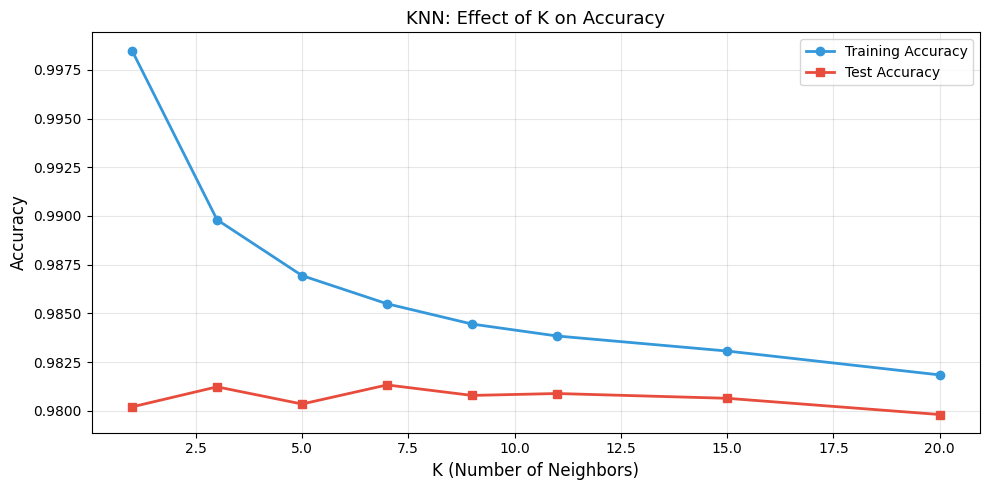

Best K: 7  (test accuracy: 0.9813)


In [76]:
# Find the best K by testing different values
k_values   = [1, 3, 5, 7, 9, 11, 15, 20]
train_accs = []
test_accs  = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, knn.predict(X_train)))
    test_accs.append(accuracy_score(y_test,  knn.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.plot(k_values, train_accs, 'o-', color='#3498DB', label='Training Accuracy', linewidth=2)
plt.plot(k_values, test_accs,  's-', color='#E74C3C', label='Test Accuracy',     linewidth=2)
plt.xlabel('K (Number of Neighbors)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('KNN: Effect of K on Accuracy', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_k = k_values[test_accs.index(max(test_accs))]
print(f'Best K: {best_k}  (test accuracy: {max(test_accs):.4f})')

---
## Part D — Train and Evaluate KNN
---

## Step 6: Train the KNN Model

In [77]:
# Train the KNN Model with the best K
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)

train_acc = accuracy_score(y_train, knn.predict(X_train))
test_acc  = accuracy_score(y_test,  knn.predict(X_test))

print('=== KNN Model Evaluation ===')
print(f'Training accuracy : {train_acc:.4f}  ({train_acc*100:.2f}%)')
print(f'Test accuracy     : {test_acc:.4f}  ({test_acc*100:.2f}%)')

=== KNN Model Evaluation ===
Training accuracy : 0.9855  (98.55%)
Test accuracy     : 0.9813  (98.13%)


In [78]:
# Detailed classification report
print('Classification Report:')
print()
print(classification_report(
    y_test,
    knn.predict(X_test),
    target_names=list(dept_map.keys())
))

Classification Report:

                      precision    recall  f1-score   support

Respiratory Medicine       0.97      0.98      0.98      4701
          Cardiology       1.00      1.00      1.00      3672
    Gastroenterology       1.00      1.00      1.00      3467
           Neurology       0.97      0.99      0.98      3263
    General Medicine       0.95      0.90      0.93      2649
         Dermatology       1.00      1.00      1.00      2648

            accuracy                           0.98     20400
           macro avg       0.98      0.98      0.98     20400
        weighted avg       0.98      0.98      0.98     20400



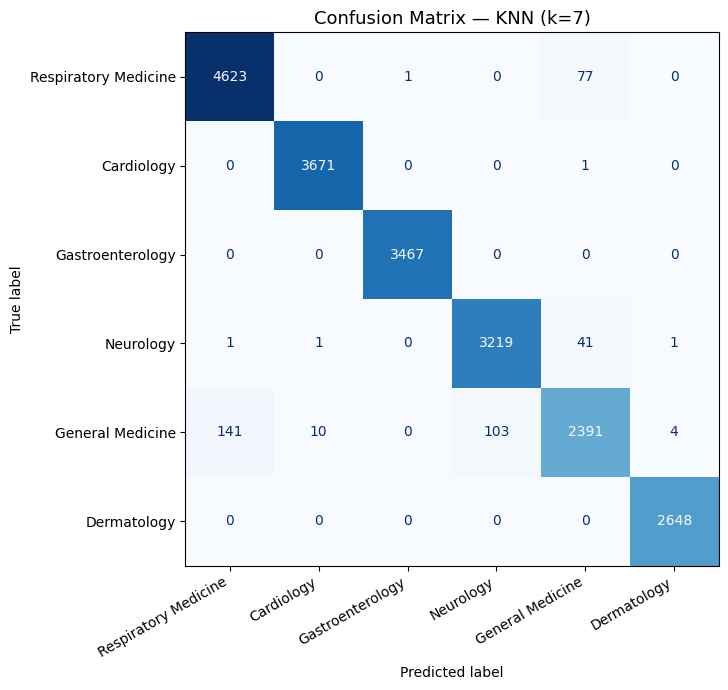

In [79]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    knn.predict(X_test),
    display_labels=list(dept_map.keys()),
    ax=ax,
    colorbar=False,
    cmap='Blues'
)
plt.title('Confusion Matrix — KNN (k=7)', fontsize=13)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

---
## Part F — Predict With User Input (Optional)
---

## Step 8: Predict with user input

In [80]:
# Available options for each field:
# chief_complaint : Fever, Cough, Headache, Chest Pain, Stomach Pain,
#                   Shortness of Breath, Nausea / Vomiting, Dizziness, Skin Rash, Other
# temperature_level: Below 37°C, 37-38°C, Above 38°C
# heart_rate_level : Below 60 bpm, 60-100 bpm, Above 100 bpm
# duration         : Less than 1 day, 1-3 days, 4-7 days, More than 1 week
# gender           : Female, Male

print('=== Smart Hospital Patient Triage ===')
print()

# User input
age               = int(input('Patient age: '))
gender            = input('Gender (Female/Male): ').strip().capitalize()
chief_complaint   = input('Chief complaint (Fever/Cough/Headache/Chest Pain/Stomach Pain/Shortness of Breath/Nausea - Vomiting/Dizziness/Skin Rash/Other): ').strip()
temperature_level = input('Temperature (Below 37°C / 37-38°C / Above 38°C): ').strip()
heart_rate_level  = input('Heart rate (Below 60 bpm / 60-100 bpm / Above 100 bpm): ').strip()
duration          = input('Duration (Less than 1 day / 1-3 days / 4-7 days / More than 1 week): ').strip()

print()
print('Symptoms (Yes/No):')
fever            = 1 if input('  Fever? ').strip().capitalize() == 'Yes' else 0
cough            = 1 if input('  Cough? ').strip().capitalize() == 'Yes' else 0
headache         = 1 if input('  Headache? ').strip().capitalize() == 'Yes' else 0
chest_pain       = 1 if input('  Chest pain? ').strip().capitalize() == 'Yes' else 0
stomach_pain     = 1 if input('  Stomach pain? ').strip().capitalize() == 'Yes' else 0
shortness_breath = 1 if input('  Shortness of breath? ').strip().capitalize() == 'Yes' else 0
nausea_vomiting  = 1 if input('  Nausea/vomiting? ').strip().capitalize() == 'Yes' else 0
dizziness        = 1 if input('  Dizziness? ').strip().capitalize() == 'Yes' else 0
skin_rash        = 1 if input('  Skin rash? ').strip().capitalize() == 'Yes' else 0

print()
print('Medical history (Yes/No):')
asthma           = 1 if input('  Asthma? ').strip().capitalize() == 'Yes' else 0
hypertension     = 1 if input('  Hypertension? ').strip().capitalize() == 'Yes' else 0
heart_disease    = 1 if input('  Heart disease? ').strip().capitalize() == 'Yes' else 0

# Encode inputs
patient = pd.DataFrame([{
    'age'              : age,
    'gender'           : gender_map.get(gender, 2),
    'fever'            : fever,
    'cough'            : cough,
    'headache'         : headache,
    'chest_pain'       : chest_pain,
    'stomach_pain'     : stomach_pain,
    'shortness_breath' : shortness_breath,
    'nausea_vomiting'  : nausea_vomiting,
    'dizziness'        : dizziness,
    'skin_rash'        : skin_rash,
    'temperature_level': temp_map.get(temperature_level, 1),
    'heart_rate_level' : hr_map.get(heart_rate_level, 1),
    'duration'         : dur_map.get(duration, 1),
    'asthma'           : asthma,
    'hypertension'     : hypertension,
    'heart_disease'    : heart_disease,
    'chief_complaint'  : cc_map.get(chief_complaint, 9)
}])

# Scale
patient_scaled = patient.copy()
patient_scaled[cols_to_scale] = scaler.transform(patient[cols_to_scale])

# Predict
pred  = knn.predict(patient_scaled[features])[0]
proba = knn.predict_proba(patient_scaled[features])[0]

dept_name  = dept_map_inv[pred]
confidence = proba[pred] * 100

print()
print('=== Triage Recommendation ===')
print(f'Recommended Department : {dept_name}')
print(f'Confidence             : {confidence:.1f}%')
print()
print('Probabilities per department:')
for i, name in dept_map_inv.items():
    print(f'  {name:<25}: {proba[i]*100:.1f}%')

=== Smart Hospital Patient Triage ===

Patient age: 21
Gender (Female/Male): Male
Chief complaint (Fever/Cough/Headache/Chest Pain/Stomach Pain/Shortness of Breath/Nausea - Vomiting/Dizziness/Skin Rash/Other): Fever
Temperature (Below 37°C / 37-38°C / Above 38°C): Below 37C
Heart rate (Below 60 bpm / 60-100 bpm / Above 100 bpm): Above 100 bpm
Duration (Less than 1 day / 1-3 days / 4-7 days / More than 1 week): 1-3 days

Symptoms (Yes/No):
  Fever? Yes
  Cough? No
  Headache? No
  Chest pain? No
  Stomach pain? No
  Shortness of breath? No
  Nausea/vomiting? No
  Dizziness? No
  Skin rash? No

Medical history (Yes/No):
  Asthma? No
  Hypertension? No
  Heart disease? No

=== Triage Recommendation ===
Recommended Department : General Medicine
Confidence             : 71.4%

Probabilities per department:
  Respiratory Medicine     : 28.6%
  Cardiology               : 0.0%
  Gastroenterology         : 0.0%
  Neurology                : 0.0%
  General Medicine         : 71.4%
  Dermatology  

---
## Part G — Save the Model
---

## Step 9: Save hospital_model.pkl

In [82]:
# Saving model with pickle
model_bundle = {
    'model'       : knn,
    'scaler'      : scaler,
    'features'    : features,
    'cols_to_scale': cols_to_scale,
    'dept_map'    : dept_map,
    'dept_map_inv': dept_map_inv,
    'gender_map'  : gender_map,
    'temp_map'    : temp_map,
    'hr_map'      : hr_map,
    'dur_map'     : dur_map,
    'cc_map'      : cc_map
}

with open('hospital_model.pkl', 'wb') as f:
    pickle.dump(model_bundle, f)

print('hospital_model.pkl saved!')
print()
print('Contents:')
print(f'  model        : KNeighborsClassifier (k=7)')
print(f'  scaler       : StandardScaler')
print(f'  features     : {features}')
print(f'  departments  : {list(dept_map.keys())}')

hospital_model.pkl saved!

Contents:
  model        : KNeighborsClassifier (k=7)
  scaler       : StandardScaler
  features     : ['age', 'gender', 'fever', 'cough', 'headache', 'chest_pain', 'stomach_pain', 'shortness_breath', 'nausea_vomiting', 'dizziness', 'skin_rash', 'temperature_level', 'heart_rate_level', 'duration', 'asthma', 'hypertension', 'heart_disease', 'chief_complaint']
  departments  : ['Respiratory Medicine', 'Cardiology', 'Gastroenterology', 'Neurology', 'General Medicine', 'Dermatology']


In [84]:
# Downloading model
from google.colab import files
files.download('hospital_model.pkl')
print('Download started! Upload this to GitHub to update your app.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started! Upload this to GitHub to update your app.


---

## Mission 1 Complete!

| Part | Steps | What You Did |
|------|-------|--------------|
| A — Preprocessing | Steps 3 | Cleaned, encoded, and prepared hospital dataset |
| B — Split & Scale | Step 4 | Split 80/20, scaled with StandardScaler |
| C — KNN Concept | Step 5 | Understood how KNN works, found best K |
| D — Train & Evaluate | Steps 6 | Trained KNN, confusion matrix, classification report |
| E — User Input | Step 8 | Predicted department with custom patient input |
| F — Save | Steps 9 | Saved hospital_model.pkl |

**Next up — Mission 2**  
In Mission 2, you'll transform your trained AI model into a real-world Smart Hospital Patient Navigator by building a **user-friendly web application** and deploying it online. This will allow patients to access your solution through a web browser
